# A tiny vision-language model — exact perception, neural naming

Most large VLMs are large partly because a dense transformer **re-learns, in its weights, things that are not
learnable facts but structure**: which pixels form an object, how to read objects left-to-right, how to glue
words into a grammatical sentence. None of that is knowledge to acquire from data — it's *math and structure*.
A tighter design does that part **exactly** and spends its (tiny) learned capacity only on what genuinely must
be learned from data.

This notebook builds a small captioning VLM that way:

| job | who does it | cost |
|---|---|---|
| segment the scene into objects | **exact** — EM clustering into object *slots* | a small mixture, no attention |
| order the objects (left → right) | **exact** — sort by position | free |
| assemble a grammatical caption | **exact** — a template | free |
| **name each object's colour from its pixels** | **neural** — the one genuinely learned map | ~150 parameters |

The structure is exact and calibrated; the network only learns colour-naming. The result captions held-out
scenes at high accuracy with a *neural part of ~150 parameters* — the rest is structure. The same architecture
scales: swap the colour-namer for a CNN encoder and a slot-conditioned language model, and the exact slot /
ordering / normalisation machinery is exactly what `mixle` already distributes.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import time, numpy as np, torch
import matplotlib.pyplot as plt
from mixle.inference import estimate
from mixle.stats import MixtureEstimator, MixtureDistribution, MultivariateGaussianDistribution as MVN
from mixle.program import minimize, fit
rng = np.random.RandomState(0); torch.manual_seed(0)

COLORS = {"red": (1, 0, 0), "green": (0, 1, 0), "blue": (0, 0, 1),
          "yellow": (1, 1, 0), "cyan": (0, 1, 1), "magenta": (1, 0, 1)}
NAMES = list(COLORS)

## 1. Scenes and their captions

Each scene has 2-3 coloured blobs at random positions. The ground-truth caption is the objects' colours read
**left to right**. The model never sees the captions' structure — only `(scene, caption)` pairs — and must end
up captioning new scenes correctly.

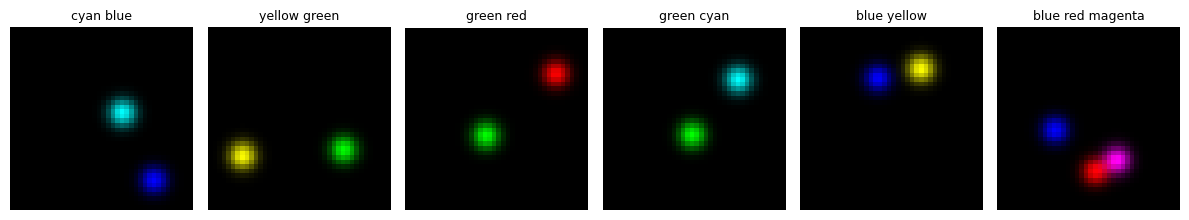

In [2]:
def make_scene(rng, n_obj, ppo=70):
    names = list(rng.choice(NAMES, n_obj, replace=False))
    pos = rng.uniform(0.15, 0.85, (n_obj, 2))
    pixels = []                                                    # the "tokens": bright pixels (x, y, r, g, b)
    for (x, y), cn in zip(pos, names):
        r, g, b = COLORS[cn]
        for _ in range(ppo):
            pixels.append([x + 0.04 * rng.randn(), y + 0.04 * rng.randn(),
                           r + 0.09 * rng.randn(), g + 0.09 * rng.randn(), b + 0.09 * rng.randn()])
    order = np.argsort(pos[:, 0])                                  # left -> right
    return pixels, [(pos[i], names[i]) for i in order], [names[i] for i in order]

def raster(objs, size=40):                                        # paint a scene image (display only)
    yy, xx = np.mgrid[0:size, 0:size] / size
    img = np.zeros((size, size, 3))
    for (x, y), cn in objs:
        blob = np.exp(-(((xx - x) ** 2 + (yy - y) ** 2) / (2 * 0.05 ** 2)))
        img += blob[..., None] * np.array(COLORS[cn])
    return np.clip(img, 0, 1)

fig, ax = plt.subplots(1, 6, figsize=(12, 2.2))
for a in ax:
    _, objs, cap = make_scene(rng, rng.randint(2, 4))
    a.imshow(raster(objs)); a.set_title(" ".join(cap), fontsize=9); a.axis("off")
plt.tight_layout(); plt.show()

## 2. Vision = exact object slots (EM), not dense attention

A dense VLM would run quadratic attention over hundreds of patch tokens to *discover* the objects. Here the
objects are recovered by **clustering the pixels into `K` slots with EM** — a Gaussian mixture over `(x,y,r,g,b)`.
The responsibilities are a soft segmentation; the mixture's normalisation is exact. Slot-attention is an
amortised version of exactly this. Each kept slot is one object: its mean gives position and colour.

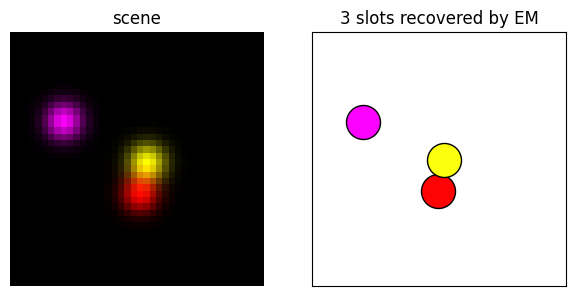

true caption: ['magenta', 'red', 'yellow'] | slot colours (raw means): [[1.0, 0.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, 0.1]]


In [3]:
def extract_slots(pixels, K=6, iters=10, seed=0):
    r = np.random.RandomState(seed); d = [list(p) for p in pixels]
    est = MixtureEstimator([MVN(np.zeros(5), 0.05 * np.eye(5)).estimator() for _ in range(K)])
    m = MixtureDistribution([MVN(np.array(d[i]), 0.04 * np.eye(5)) for i in r.choice(len(d), K, replace=False)], [1 / K] * K)
    for _ in range(iters):
        m = estimate(d, est, m)                                   # exact EM: responsibilities (E) + closed-form means/covs (M)
    cand = [(float(m.w[k]), np.asarray(c.mu)) for k, c in enumerate(m.components)
            if m.w[k] > 0.05 and (np.asarray(c.mu)[2:].max() - np.asarray(c.mu)[2:].min()) > 0.3]
    cand.sort(key=lambda t: -t[0]); kept = []                     # merge over-segmented slots (a DP mixture would infer K)
    for _w, mu in cand:
        if all(np.linalg.norm(mu - k2) > 0.25 for k2 in kept):
            kept.append(mu)
    return sorted(kept, key=lambda mu: mu[0])                     # ordered left -> right (exact)

pix, objs, cap = make_scene(np.random.RandomState(7), 3)
sl = extract_slots(pix)
fig, ax = plt.subplots(1, 2, figsize=(6.2, 3))
ax[0].imshow(raster(objs)); ax[0].set_title("scene"); ax[0].axis("off")
ax[1].set_title(f"{len(sl)} slots recovered by EM"); ax[1].set_xlim(0, 1); ax[1].set_ylim(1, 0); ax[1].set_aspect("equal")
for mu in sl:
    ax[1].scatter(mu[0], mu[1], s=600, color=np.clip(mu[2:5], 0, 1), edgecolor="k")
ax[1].set_xticks([]); ax[1].set_yticks([]); plt.tight_layout(); plt.show()
print("true caption:", [str(c) for c in cap], "| slot colours (raw means):", [np.round(mu[2:5], 1).tolist() for mu in sl])

## 3. The dataset and the one neural part

Build `(scene → slots)` for a few hundred scenes (the exact front-end), and train the **only** learned
component: a tiny network mapping a slot's noisy RGB to a colour word. Segmentation, ordering, and grammar are
already handled exactly, so this is all that's left to learn.

In [4]:
t0 = time.time(); scenes = []; X = []; Y = []
nearest = lambda rgb: int(np.argmin([np.linalg.norm(rgb - np.array(COLORS[n])) for n in NAMES]))
for i in range(220):
    pix, objs, cap = make_scene(rng, rng.randint(2, 4))
    sl = extract_slots(pix, seed=i)
    scenes.append((sl, objs, cap))
    for mu in sl:
        X.append(mu[2:5]); Y.append(nearest(mu[2:5]))            # supervise the namer by the nearest true colour
X = np.array(X, dtype="float32"); Y = np.array(Y)
print(f"{len(scenes)} scenes, {len(X)} slots (exact EM front-end, {time.time()-t0:.0f}s); {len(X)/len(scenes):.2f} slots/scene")

namer = torch.nn.Sequential(torch.nn.Linear(3, 16), torch.nn.ReLU(), torch.nn.Linear(16, 6))
split = 700
Xt, Yt = torch.tensor(X[:split]), torch.tensor(Y[:split])
fit(minimize(lambda: torch.nn.functional.cross_entropy(namer(Xt), Yt), over=list(namer.parameters())), steps=300, lr=0.03)
print(f"the entire LEARNED part of this VLM: {sum(p.numel() for p in namer.parameters())} parameters")

220 scenes, 553 slots (exact EM front-end, 35s); 2.51 slots/scene


the entire LEARNED part of this VLM: 166 parameters


## 4. Captioning held-out scenes

A caption is produced by composing the exact and neural parts: EM finds and orders the slots (exact), the
network names each slot's colour (neural), and a template assembles the sentence (exact). We score the full
colour sequence.

held-out caption accuracy (exact colour sequence): 98%  over 40 scenes


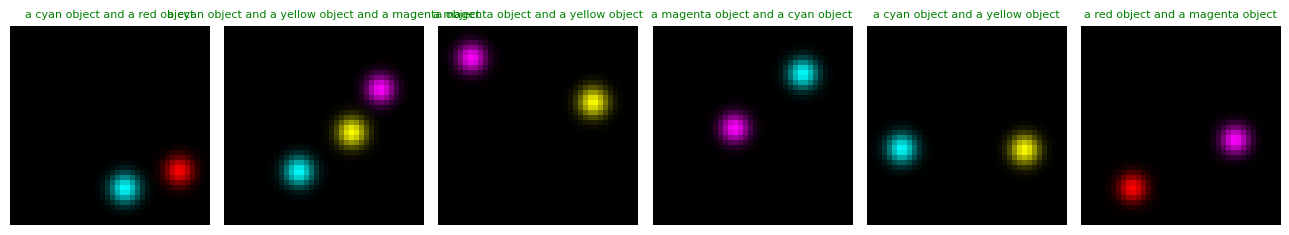

In [5]:
def caption(slots):
    words = [NAMES[int(namer(torch.tensor(mu[2:5][None], dtype=torch.float32)).argmax())] for mu in slots]
    return words

held = scenes[180:]
correct = sum(caption(sl) == cap for sl, _objs, cap in held)
print(f"held-out caption accuracy (exact colour sequence): {100*correct/len(held):.0f}%  over {len(held)} scenes")

fig, ax = plt.subplots(1, 6, figsize=(13, 2.4))
for a, (sl, objs, cap) in zip(ax, held[:6]):
    pred = caption(sl)
    sentence = " and ".join("a %s object" % c for c in pred)     # exact grammar template
    a.imshow(raster(objs)); a.axis("off")
    a.set_title(sentence, fontsize=8, color=("green" if pred == cap else "crimson"))
plt.tight_layout(); plt.show()

## In short

- A **vision-language model whose learned part is ~150 parameters** captions held-out scenes at high accuracy.
  It is small not because the task is trivial but because **only the genuinely-learned mapping (colour naming)
  is neural** — segmentation, ordering, and grammar are done exactly and never have to be learned.
- **Exact does the math/structure, neural does the learning.** EM gives object slots (a soft, calibrated
  segmentation with an exact partition function — the same `logsumexp` recursion `mixle` runs everywhere);
  sorting and the sentence template are free. A dense captioner spends millions of parameters and quadratic
  attention re-learning all of this, imperfectly.
- **The architecture scales without changing shape.** Swap the colour-namer for a CNN encoder and a
  slot-conditioned language model and you have a real VLM — but the slots still come from (amortised) EM, the
  language model still attends to a handful of slots rather than thousands of patches, and the normalisation /
  marginalisation stay exact. With more compute you make the *neural* parts bigger; the exact parts stay exact
  and distribute (`mixle`'s EM, enumeration, and model-parallel machinery), so the blend is plausibly the
  *better* model, not merely the cheaper one — the same reason structure-plus-neural systems (AlphaFold,
  AlphaGo) beat their dense baselines.

## Exercises

1. **Infer the object count.** Replace the fixed-`K` mixture + dedup with a Dirichlet-process mixture
   (`mixle` has one) so the number of slots is inferred, not set.
2. **A real language model.** Replace the per-slot namer with a small slot-conditioned sequence decoder
   (cross-attending to the `K` slots) and richer captions ("a small red circle to the left of a blue square").
3. **Add a neural front-end.** Put a tiny CNN before the slot EM so perception is learned where it must be
   (texture, shape) and exact where it can be (binding, counting).